### Procesamiento de Lenguaje Natural I
# **Desafío 1**



### Vectorización de texto y modelo de clasificación Naïve Bayes con el dataset 20 newsgroups

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import f1_score

Utilizamos **20newsgroups** por ser un dataset clásico de NLP ya viene incluido y formateado en sklearn

In [2]:
from sklearn.datasets import fetch_20newsgroups
import numpy as np

## Carga de datos

Cargamos los datos (ya separados de forma predeterminada en train y test)

El dataset 20 Newsgroups contiene aproximadamente 18 000 publicaciones de grupos de noticias distribuidas en 20 temas. Está dividido en dos subconjuntos: uno para entrenamiento (train set) y otro para pruebas (test set).

In [3]:
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

In [4]:
newsgroups_train.keys()

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

In [5]:
newsgroups_train.target

array([7, 4, 4, ..., 3, 1, 8])

## Vectorización

Instanciamos un vectorizador.

Podemos ver diferentes parámetros de instanciación en la documentación de sklearn https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [6]:
tfidfvect = TfidfVectorizer()

En el atributo `data` accedemos al texto

In [7]:
print(newsgroups_train.data[0])

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


Con la interfaz habitual de sklearn podemos ajustar el vectorizador (obtener el vocabulario y calcular el vector IDF) y transformar directamente los datos.

Podemos denominar `X_train` como la matriz documento-término.

In [8]:
X_train = tfidfvect.fit_transform(newsgroups_train.data)

Recordemos que las vectorizaciones por conteos son de tipo sparse, por ello sklearn convenientemente devuelve los vectores de documentos como matrices de tipo sparse.

In [9]:
print(type(X_train))
print(f'shape: {X_train.shape}')
print(f'Cantidad de documentos: {X_train.shape[0]}')
print(f'Tamaño del vocabulario (dimensionalidad de los vectores): {X_train.shape[1]}')

<class 'scipy.sparse._csr.csr_matrix'>
shape: (11314, 101631)
Cantidad de documentos: 11314
Tamaño del vocabulario (dimensionalidad de los vectores): 101631


Una vez ajustado el vectorizador, podemos acceder a atributos como el vocabulario aprendido. Es un diccionario que va de términos a índices.

El índice es la posición en el vector de documento.

In [10]:
tfidfvect.vocabulary_['car']

25775

Probamos con una palbra que no está en el documento.

In [11]:
tfidfvect.vocabulary_['cocoliso']

KeyError: 'cocoliso'

Es muy útil tener el diccionario opuesto que va de índices a términos

In [12]:
idx2word = {v: k for k,v in tfidfvect.vocabulary_.items()}

In [13]:
idx2word[2]

'0000'

En `y_train` guardamos los targets que son enteros

In [14]:
y_train = newsgroups_train.target
y_train[:10]

array([ 7,  4,  4,  1, 14, 16, 13,  3,  2,  4])

Hay 20 clases correspondientes a los 20 grupos de noticias

In [15]:
print(f'clases {np.unique(newsgroups_test.target)}')
newsgroups_test.target_names

clases [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

## Similaridad de documentos

Veamos similaridad de documentos. Tomemos algún documento

In [16]:
idx = 4811
print(newsgroups_train.data[idx])

THE WHITE HOUSE

                  Office of the Press Secretary
                   (Pittsburgh, Pennslyvania)
______________________________________________________________
For Immediate Release                         April 17, 1993     

             
                  RADIO ADDRESS TO THE NATION 
                        BY THE PRESIDENT
             
                Pittsburgh International Airport
                    Pittsburgh, Pennsylvania
             
             
10:06 A.M. EDT
             
             
             THE PRESIDENT:  Good morning.  My voice is coming to
you this morning through the facilities of the oldest radio
station in America, KDKA in Pittsburgh.  I'm visiting the city to
meet personally with citizens here to discuss my plans for jobs,
health care and the economy.  But I wanted first to do my weekly
broadcast with the American people. 
             
             I'm told this station first broadcast in 1920 when
it reported that year's presidential elec

Medimos la similaridad coseno con todos los documentos de train

In [17]:
cossim = cosine_similarity(X_train[idx], X_train)[0]

Podemos ver los valores de similaridad ordenados de mayor a menor

In [18]:
np.sort(cossim)[::-1]

array([1.        , 0.70930477, 0.67474953, ..., 0.        , 0.        ,
       0.        ])

Después vemos a qué documentos corresponden

In [19]:
np.argsort(cossim)[::-1]

array([4811, 6635, 4253, ..., 1911, 1825, 1828])

Obtenemos los 5 documentos más similares:

In [20]:
mostsim = np.argsort(cossim)[::-1][1:6]
print(mostsim)

[6635 4253 3596 4271 3746]


El documento original pertenece a la clase:

In [21]:
newsgroups_train.target_names[y_train[idx]]

'talk.politics.misc'

Revisamos las clases de los 5 más similares:

In [22]:
for i in mostsim:
  print(newsgroups_train.target_names[y_train[i]])

talk.politics.misc
talk.politics.misc
talk.politics.misc
talk.politics.misc
talk.politics.misc


### Modelo de clasificación Naïve Bayes

Instanciamos el modelo de clasificación Naive Bayes y lo entrenamos con sklearn

In [23]:
clf = MultinomialNB()
clf.fit(X_train, y_train)

MultinomialNB()

Ya tenemos nuestro vectorizador ya ajustado en train, vectorizamos los textos
del conjunto de test.

In [24]:
X_test = tfidfvect.transform(newsgroups_test.data)
y_test = newsgroups_test.target
y_pred =  clf.predict(X_test)

El F1-score es una métrica adecuada para evaluar el desempeño de modelos de clasificación, especialmente cuando existe desbalance entre clases.

* El promediado macro calcula el promedio del F1-score de cada clase, otorgando el mismo peso a todas las clases.
* El promediado micro calcula las métricas de forma global considerando todas las predicciones; en problemas de clasificación multiclase suele ser equivalente a la accuracy, por lo que no es la mejor métrica cuando el dataset está desbalanceado.

In [25]:
f1_score(y_test, y_pred, average='macro')

0.5854345727938506

---

## **Consigna del Desafío 1**
**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado.**



**1. Vectorizar documentos**
* Tomar 5 documentos al azar y medir similaridad con el resto de los documentos.
Estudiar los 5 documentos más similares de cada uno analizar si tiene sentido
la similaridad según el contenido del texto y la etiqueta de clasificación.

**2. Construir un modelo de clasificación por prototipos (tipo zero-shot).**
* Clasificar los documentos de un conjunto de test comparando cada uno con todos los de entrenamiento y asignar la clase al label del documento del conjunto de entrenamiento con mayor similaridad.

**3. Entrenar modelos de clasificación Naïve Bayes para maximizar el desempeño de clasificación**

* F1-Score Macro en el conjunto de datos de test. Considerar cambiar parámetros
de instanciación del vectorizador y los modelos y probar modelos de Naïve Bayes Multinomial y ComplementNB.

**NO cambiar el hiperparámetro ngram_range de los vectorizadores**.

**4. Transponer la matriz documento-término.**
* De esa manera se obtiene una matriz término-documento que puede ser interpretada como una colección de vectorización de palabras.
* Estudiar ahora similaridad entre palabras tomando 5 palabras y estudiando sus 5 más similares.

**Elegir las palabras MANUALMENTE para evitar la aparición de términos poco interpretables**.


### (1) Vectorizar documentos

In [26]:
ids = [3776, 7062, 8202, 5656, 4024]

In [27]:
import numpy as np
# Punto 1
#ids = np.random.randint(0, X_train.shape[0], 5)
print(ids)

[3776, 7062, 8202, 5656, 4024]


Se comenta el randint anterior para no cambiar el output de las siguientes celdas ya que las conclusiones estan realizadas con los documentos de la lista ids actual

In [28]:
for idx in ids:
  print(newsgroups_train.target_names[y_train[idx]])

talk.politics.mideast
comp.os.ms-windows.misc
sci.med
rec.autos
talk.politics.misc


Para cumplir con la consigna y hacer que el resultado sea más fácil de interpretar, crearemos una función que muestre el contenido completo del documento original y de sus 5 documentos más similares, incluyendo sus etiquetas y la puntuación de similaridad coseno.

In [29]:
def display_similar_documents(original_idx, X_matrix, newsgroups_data, max_chars=500):
  """
  Calcula y muestra los 5 documentos más similares a un documento dado.

  Args:
    original_idx (int): Índice del documento original en newsgroups_data.
    X_matrix (scipy.sparse.csr_matrix): Matriz de documentos vectorizados (X_train).
    newsgroups_data (Bunch): Objeto Bunch de scikit-learn con 'data', 'target', 'target_names'.
    max_chars (int): Número máximo de caracteres a mostrar del contenido del documento.
  """
  print(f"\n--- Documento Original (ID: {original_idx}) ---")
  print(f"Clase: {newsgroups_data.target_names[newsgroups_data.target[original_idx]]}")
  print("Contenido:\n")
  doc_content = newsgroups_data.data[original_idx]
  if len(doc_content) > max_chars:
    print(doc_content[:max_chars] + "\n[...TRUNCATED...]")
  else:
    print(doc_content)

  cossim = cosine_similarity(X_matrix[original_idx], X_matrix)[0]
  # Obtenemos los 5 documentos más similares, excluyendo el propio documento (que tendrá similaridad 1)
  most_similar_indices = np.argsort(cossim)[::-1][1:6]

  print("\n--- 5 Documentos Más Similares ---")
  for i, sim_idx in enumerate(most_similar_indices):
    similarity_score = cossim[sim_idx]
    print(f"\n{i+1}. Documento Similar (ID: {sim_idx}, Similaridad: {similarity_score:.4f})")
    print(f"Clase: {newsgroups_data.target_names[newsgroups_data.target[sim_idx]]}")
    print("Contenido:\n")
    doc_content_similar = newsgroups_data.data[sim_idx]
    if len(doc_content_similar) > max_chars:
      print(doc_content_similar[:max_chars] + "\n[...TRUNCATED...]")
    else:
      print(doc_content_similar)

In [30]:
for doc_id in ids:
  display_similar_documents(doc_id, X_train, newsgroups_train, max_chars=500)


--- Documento Original (ID: 3776) ---
Clase: talk.politics.mideast
Contenido:

I will try to answer some of Dorin's questions, even though they were
not addressed to me specifically, but I feel that I am a bit concerned
by the thread since I am a Southern Lebanese from a village that is 
often on the receiving end of Israel's bombs.
In the first place the death of three soldiers on a patrol in occupied
Lebanese terrritory is NOT an act of terrorism or murder.  It is 
disingeneous to compare their death to that of athletes in Munich
or any other act of terrorism or mrder.  
[...TRUNCATED...]

--- 5 Documentos Más Similares ---

1. Documento Similar (ID: 11305, Similaridad: 0.7971)
Clase: talk.politics.mideast
Contenido:

   [snip]
   In the first place the death of three soldiers on a patrol in occupied
   Lebanese terrritory is NOT an act of terrorism or murder.  It is 
   disingeneous to compare their death to that of athletes in Munich
   or any other act of terrorism or mrder.  Thi

#### 1.1 Tabla Resumen de Similaridades

In [31]:
import pandas as pd

similarity_results = []

for doc_id in ids:
    original_class = newsgroups_train.target_names[newsgroups_train.target[doc_id]]

    cossim = cosine_similarity(X_train[doc_id], X_train)[0]
    most_similar_indices = np.argsort(cossim)[::-1][1:6] # Excluir el propio documento

    similar_docs_info = []
    for sim_idx in most_similar_indices:
        sim_class = newsgroups_train.target_names[newsgroups_train.target[sim_idx]]
        similarity_score = cossim[sim_idx]
        similar_docs_info.append(f"{sim_class} ({similarity_score:.4f})")

    similarity_results.append({
        'Original ID': doc_id,
        'Original Class': original_class,
        'Similar Doc 1': similar_docs_info[0],
        'Similar Doc 2': similar_docs_info[1],
        'Similar Doc 3': similar_docs_info[2],
        'Similar Doc 4': similar_docs_info[3],
        'Similar Doc 5': similar_docs_info[4]
    })

df_similarity = pd.DataFrame(similarity_results)
display(df_similarity)

,Original ID,Original Class,Similar Doc 1,Similar Doc 2,Similar Doc 3,Similar Doc 4,Similar Doc 5
0,3776,talk.politics.mideast,talk.politics.mideast (0.7971),talk.politics.mideast (0.5894),talk.politics.mideast (0.5709),talk.politics.mideast (0.5703),talk.politics.mideast (0.5540)
1,7062,comp.os.ms-windows.misc,comp.os.ms-windows.misc (0.4527),comp.os.ms-windows.misc (0.4514),comp.os.ms-windows.misc (0.3881),comp.os.ms-windows.misc (0.3411),comp.os.ms-windows.misc (0.3384)
2,8202,sci.med,sci.med (0.1854),rec.sport.hockey (0.1533),sci.med (0.1418),sci.med (0.1396),sci.med (0.1294)
3,5656,rec.autos,rec.autos (0.3110),rec.autos (0.2488),rec.autos (0.2432),rec.autos (0.2344),rec.autos (0.2285)
4,4024,talk.politics.misc,talk.politics.mideast (0.2769),alt.atheism (0.2649),alt.atheism (0.2592),talk.politics.guns (0.2582),soc.religion.christian (0.2570)


#### 1.2 Análisis de la Similitud de Documentos

El formato y la estructura del texto importan en el cálculo de la similitud, ya que el `TfidfVectorizer` opera a nivel de las palabras y su frecuencia. Un formato diferente puede implicar distintas palabras, una distribución diferente de las mismas, o incluso la presencia de caracteres especiales que afectan la vectorización, y por ende, la similitud coseno.

Observando los resultados, podemos extraer varias conclusiones:

1.  **Documento Original (ID: 3776 - `talk.politics.mideast`):** Los 5 documentos más similares pertenecen a la misma clase, lo cual es un indicador fuerte de la coherencia del vectorizador. El hecho de que los textos sean parecidos, incluso con 'snips' que parecen replicar partes del original, refuerza que el TF-IDF está capturando muy bien el contenido temático. La variación en el formato en el quinto documento similar podría justificar una similaridad ligeramente menor, a pesar de compartir el tema y la clase.

2.  **Documento Original (ID: 7062 - `comp.os.ms-windows.misc`):** Es interesante notar que, aunque todos los documentos similares pertenecen a la misma clase (`comp.os.ms-windows.misc`), las puntuaciones de similaridad son más bien bajas (entre 0.33 y 0.45). Esto se alinea con el hecho de que la categoría 'misc' implica una gran variedad de temas dentro de Windows. El `TfidfVectorizer` puede identificar que todos hablan de 'Windows' por palabras comunes generales dentro de la tematica, pero la especificidad del tema dentro de esos documentos varía mucho, resultando en vectores menos cercanos entre sí.

3.  **Documento Original (ID: 8202 - `sci.med`):** Aquí se observa una mayor dispersión en las clases de los documentos similares y puntuaciones de similitudes generalmente bajas. La mención de 'liver' en documentos de clases diferentes (`sci.med` y `rec.sport.hockey`) pero con baja similitudes coseno, sugiere que el TF-IDF, aunque capta la presencia de esa palabra, no considera que el contexto general del documento sea lo suficientemente parecido como para generar una alta similitud. Es un buen ejemplo de cómo una sola palabra no define completamente la similitud global del documento.

4. **Documento Original (ID: 5656 - `rec.autos`):** En este caso, si bien todos los documentos más similares pertenecen a la misma clase (`rec.autos`), las puntuaciones de similitud son relativamente bajas, oscilando entre 0.22 y 0.31. Esto sugiere que, aunque la categoría `rec.autos` es temáticamente cohesiva y el `TfidfVectorizer` es efectivo en agrupar documentos con un vocabulario y enfoque relacionados, las variaciones en el contenido específico de los textos dentro de esta clase impiden alcanzar similitudes elevadas. La baja similitud, a pesar de la consistencia de clase, indica que incluso dentro de un dominio bien definido, la diversidad de subtemas o la granularidad de los detalles textuales pueden influir significativamente en la proximidad vectorial.

5.  **Documento Original (ID: 4024 - `talk.politics.misc`):** El comportamiento aquí es similar al del documento de `comp.os.ms-windows.misc`. La naturaleza 'misc' de la categoría `talk.politics.misc` hace que los documentos sean muy variados en contenido específico, incluso si pertenecen a la política. Las bajas similitudes y la aparición de documentos de otras clases (`alt.atheism`, `talk.politics.guns`, `soc.religion.christian`) como los 'más similares' (aunque con puntuaciones bajas) confirman que el vectorizador lucha por encontrar una alta coherencia temática en esta categoría tan amplia. Esto resalta que la similitudes coseno es sensible a la distribución general de términos, y en categorías 'misceláneas', esta distribución puede ser heterogénea.

En general, el `TfidfVectorizer` es muy efectivo para identificar la similaridad temática cuando las categorías son bien definidas y los documentos son coherentes en su contenido. Sin embargo, en categorías muy amplias o 'misceláneas', la similitud tiende a ser más baja y menos predictiva de la clase exacta, debido a la diversidad de temas que pueden abarcar.

### (2) Construir un modelo de clasificación por prototipos (tipo zero-shot).

In [32]:
def clasificacion_zero_shot(X_train_matrix, test_doc_vector, y_train_labels):
  """
  Clasifica un documento de test comparándolo con todos los documentos de entrenamiento.
  Asigna la clase del documento de entrenamiento con mayor similaridad.

  Args:
    X_train_matrix (scipy.sparse.csr_matrix): Matriz de documentos vectorizados de entrenamiento.
    test_doc_vector (scipy.sparse.csr_matrix): Vector de documento de test a clasificar.
    y_train_labels (numpy.ndarray): Etiquetas de clase de los documentos de entrenamiento.

  Returns:
    int: La etiqueta de clase predicha para el documento de test.
  """
  cossim = cosine_similarity(test_doc_vector, X_train_matrix)[0]
  # Obtenemos el índice del documento de entrenamiento más similar.
  # Aquí usamos [0] porque el documento de test no está en X_train_matrix,
  # así que el más similar es el que realmente queremos.
  most_similar_train_idx = np.argsort(cossim)[::-1][0]

  # La clase predicha es la clase del documento de entrenamiento más similar.
  predicted_class_label = y_train_labels[most_similar_train_idx]
  return predicted_class_label

In [33]:
X_test_zero_shot = tfidfvect.transform(newsgroups_test.data)
y_test_zero_shot = newsgroups_test.target

In [34]:
y_pred_zero_shot = []

# Iteramos sobre cada documento del conjunto de test por su índice
for i in range(X_test_zero_shot.shape[0]):
  # Pasamos el vector de un documento de test y la matriz de entrenamiento con sus etiquetas
  predicted_label = clasificacion_zero_shot(X_train, X_test_zero_shot[i], y_train)
  y_pred_zero_shot.append(predicted_label)

# Convertimos la lista de predicciones a un array de numpy para evaluación
y_pred_zero_shot = np.array(y_pred_zero_shot)

# Evaluamos el modelo de clasificación zero-shot
f1_zero_shot = f1_score(y_test_zero_shot, y_pred_zero_shot, average='macro')
print(f"F1-Score Macro del modelo de Clasificación Zero-Shot: {f1_zero_shot:.4f}")

F1-Score Macro del modelo de Clasificación Zero-Shot: 0.5050


**Matriz de Confusión para el Modelo Zero-Shot**: Para entender mejor el rendimiento por clase y dónde ocurren los errores de clasificación, generaremos y visualizaremos la matriz de confusión.

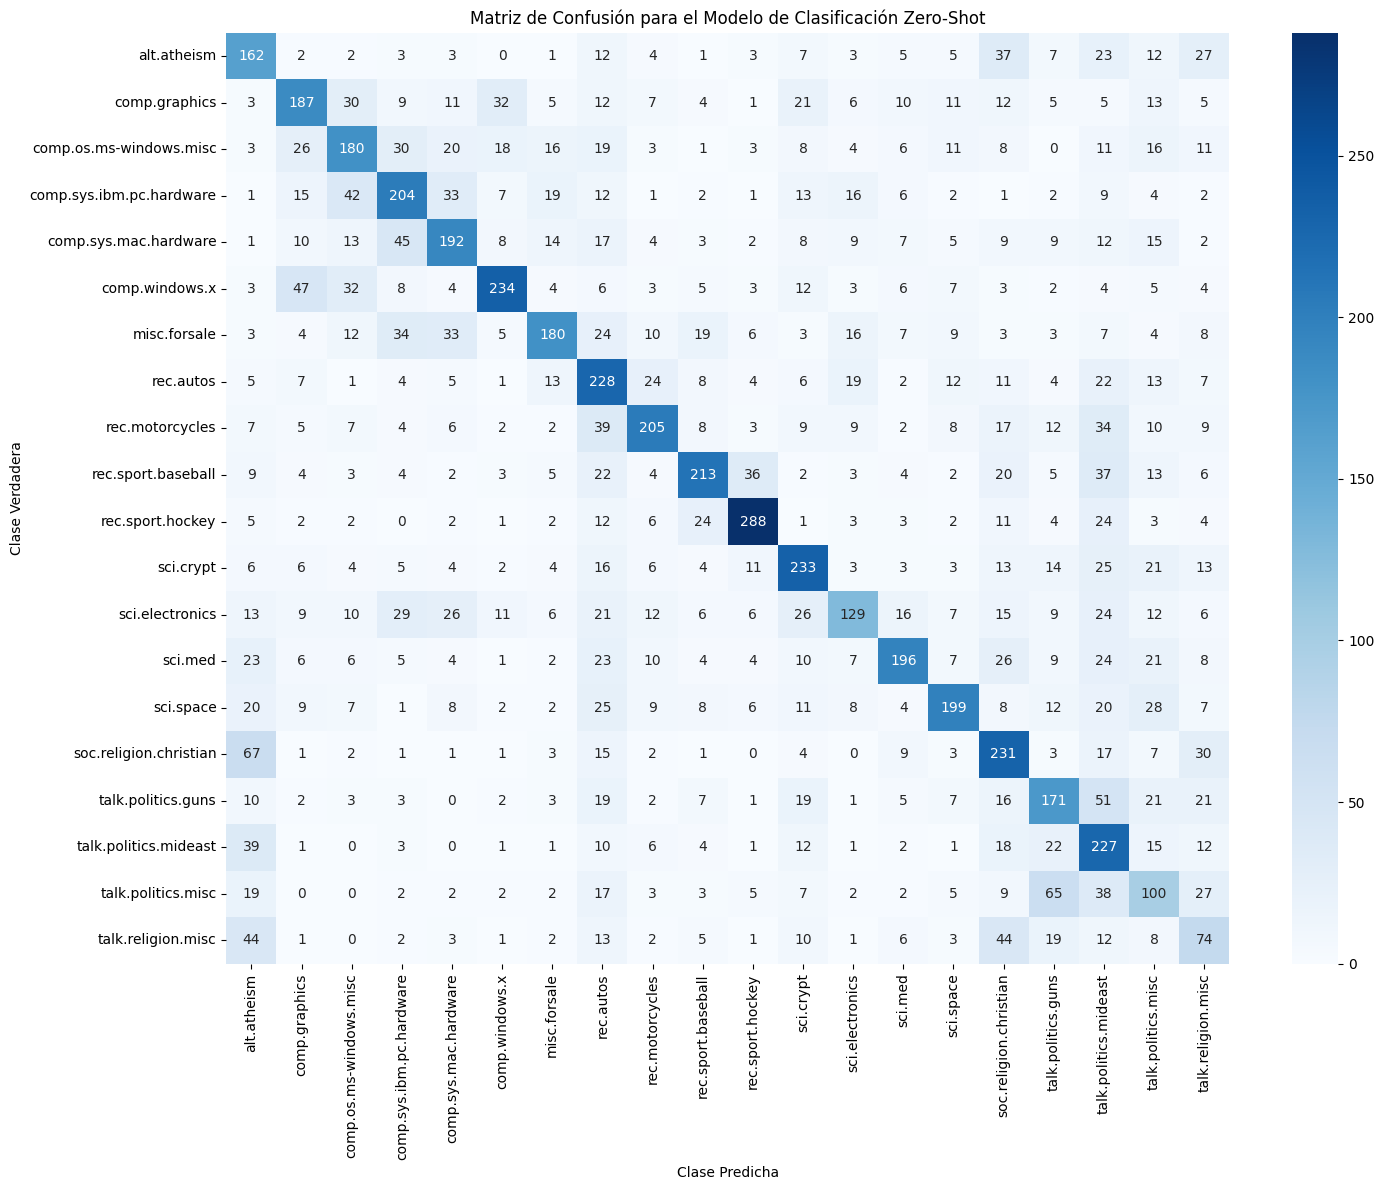

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generar la matriz de confusión
cm = confusion_matrix(y_test_zero_shot, y_pred_zero_shot)

# Visualizar la matriz de confusión
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=newsgroups_test.target_names,
            yticklabels=newsgroups_test.target_names)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión para el Modelo de Clasificación Zero-Shot')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

El modelo de clasificación Zero-Shot basado en similitud coseno obtuvo un F1-Score Macro de 0.50, lo cual representa un desempeño moderado considerando que no requirió entrenamiento supervisado con las categorías objetivo. La matriz de confusión revela que el modelo logra discriminar correctamente clases con contenido semántico bien definido y diferenciado, como rec.sport.hockey, soc.religion.christian y sci.crypt. Sin embargo, se observan confusiones sistemáticas en grupos de categorías temáticamente cercanas: las clases de política (talk.politics.) y de hardware (comp.sys.) presentan superposiciones considerables entre sí. Un caso particular son las categorías talk.politics.misc y talk.religion.misc, que muestran el peor desempeño del conjunto; esto puede atribuirse no solo a la similitud semántica con otras clases del mismo dominio, sino también a la naturaleza inherentemente heterogénea de las categorías "misc", que agrupan textos variados sin un perfil temático uniforme, dificultando su representación vectorial y, en consecuencia, su correcta clasificación por similitud.


### (3) Entrenar modelos de clasificación Naïve Bayes para maximizar el desempeño de clasificación

### 3.1 Entrenando y Optimizando `MultinomialNB`

Para maximizar el F1-Score, afinaremos los hiperparámetros del `TfidfVectorizer` y del `MultinomialNB` utilizando `GridSearchCV`. Esto explorará combinaciones de parámetros de manera eficiente.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Definir el pipeline con el vectorizador y el clasificador
# El vectorizer ya está instanciado como tfidfvect, pero para GridSearchCV
# necesitamos re-instanciarlo dentro del pipeline para poder tunear sus parámetros.
# No ajustamos tfidfvect de nuevo aquí, sino que GridSearchCV lo hará internamente.
pipeline_mnb = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('mnb', MultinomialNB())
])

# Definir el espacio de búsqueda de parámetros
# NOTA: no se cambia 'ngram_range' Ssegún la consigna
parameters_mnb = {
    'tfidf__min_df': [1, 5, 10], # Ignora términos que aparecen en menos de 'min_df' documentos
    'tfidf__max_df': [0.7, 0.9, 1.0], # Ignora términos que aparecen en más de 'max_df' documentos
    'tfidf__use_idf': [True, False], # Habilita/deshabilita IDF
    'tfidf__norm': ['l1', 'l2'], # Normalización de los vectores TF-IDF
    'mnb__alpha': [0.1, 0.5, 1.0, 2.0] # Parámetro de suavizado de Laplace para MNB
}

# Configurar GridSearchCV
# n_jobs=-1 usa todos los núcleos de la CPU disponibles
grid_search_mnb = GridSearchCV(pipeline_mnb, parameters_mnb, cv=3, n_jobs=-1, verbose=1, scoring='f1_macro')

# Ejecutar la búsqueda en la cuadrícula
grid_search_mnb.fit(newsgroups_train.data, y_train)

# Mostrar los mejores parámetros y el mejor score
print("\n--- Mejores parámetros para MultinomialNB ---")
print(grid_search_mnb.best_params_)
print("\n--- Mejor F1-Score Macro para MultinomialNB ---")
print(f"{grid_search_mnb.best_score_:.4f}")

# Guardar el mejor modelo
best_mnb_model = grid_search_mnb.best_estimator_


Fitting 3 folds for each of 144 candidates, totalling 432 fits

--- Mejores parámetros para MultinomialNB ---
{'mnb__alpha': 0.1, 'tfidf__max_df': 0.7, 'tfidf__min_df': 5, 'tfidf__norm': 'l2', 'tfidf__use_idf': True}

--- Mejor F1-Score Macro para MultinomialNB ---
0.7160


#### Evaluación del Mejor Modelo `MultinomialNB` en el conjunto de Test

Una vez encontrado el mejor modelo, lo evaluamos en el conjunto de test para obtener una estimación imparcial de su rendimiento.

In [37]:
y_pred_mnb = best_mnb_model.predict(newsgroups_test.data)
f1_mnb_test = f1_score(y_test, y_pred_mnb, average='macro')
print(f"F1-Score Macro del mejor modelo MultinomialNB en el conjunto de Test: {f1_mnb_test:.4f}")

F1-Score Macro del mejor modelo MultinomialNB en el conjunto de Test: 0.6746


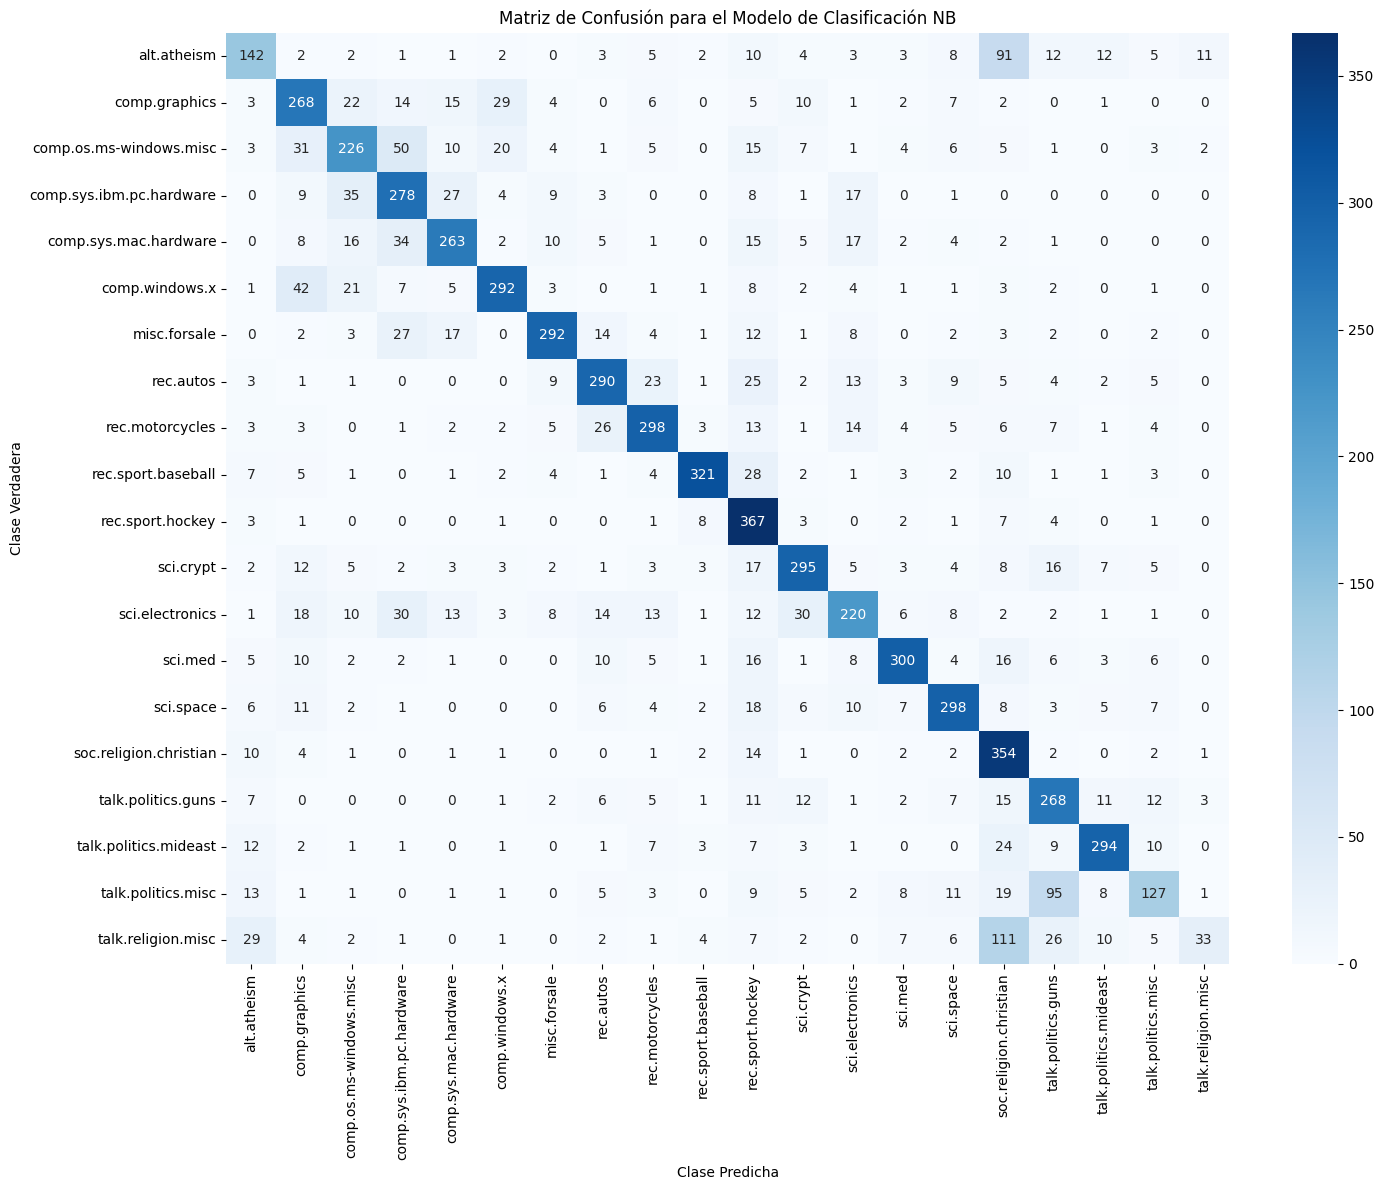

In [38]:
# Generar la matriz de confusión
cm_NB = confusion_matrix(y_test, y_pred_mnb)

# Visualizar la matriz de confusión
plt.figure(figsize=(15, 12))
sns.heatmap(cm_NB, annot=True, fmt='d', cmap='Blues',
            xticklabels=newsgroups_test.target_names,
            yticklabels=newsgroups_test.target_names)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión para el Modelo de Clasificación NB')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Mediante `GridSearchCV` con validación cruzada de 3 folds se encontró la combinación de hiperparámetros que optimiza el desempeño del modelo `MultinomialNB`: `alpha=0.1`, `max_df=0.7`, `min_df=5`, `norm='l2'` y `use_idf=True`.

El mejor F1-Score Macro obtenido en validación cruzada sobre el conjunto de entrenamiento fue de **0.7160**, mientras que al evaluar el modelo sobre el conjunto de test se obtuvo un F1-Score Macro de **0.6746**. La diferencia entre ambos valores indica un leve overfitting, esperado en modelos de texto dado el tamaño del vocabulario.

Sin embargo, el modelo representa una mejora sustancial respecto al modelo de clasificación Zero-Shot basado en similitud coseno, que había obtenido un F1-Score Macro de **0.5050** en test. Esto demuestra que el entrenamiento supervisado con `MultinomialNB`, incluso con hiperparámetros optimizados de forma básica, supera considerablemente a un enfoque no supervisado para esta tarea.

### 3.2 Entrenando y Optimizando `ComplementNB`

Para maximizar el F1-Score, afinaremos los hiperparámetros del `TfidfVectorizer` y del `ComplementNB` utilizando `GridSearchCV`. Esto explorará combinaciones de parámetros de manera eficiente. Repetimos el mismo proceso de búsqueda de hiperparámetros que hicimos para `MultinomialNB`.

In [39]:
pipeline_cnb = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('cnb', ComplementNB())
])

# NOTA: NO SE DEBE CAMBIAR 'ngram_range' SEGUN LA CONSIGNA
parameters_cnb = {
    'tfidf__min_df': [1, 5, 10],
    'tfidf__max_df': [0.7, 0.9, 1.0],
    'tfidf__use_idf': [True, False],
    'tfidf__norm': ['l1', 'l2'],
    'cnb__alpha': [0.1, 0.5, 1.0, 2.0],
    'cnb__norm': [True, False]  # parametro propio de ComplementNB (no confundir con tfidf__norm)
}

grid_search_cnb = GridSearchCV(pipeline_cnb, parameters_cnb, cv=3, n_jobs=-1, verbose=1, scoring='f1_macro')
grid_search_cnb.fit(newsgroups_train.data, y_train)

print("\n--- Mejores parámetros para ComplementNB ---")
print(grid_search_cnb.best_params_)
print("\n--- Mejor F1-Score Macro para ComplementNB ---")
print(f"{grid_search_cnb.best_score_:.4f}")

best_cnb_model = grid_search_cnb.best_estimator_

Fitting 3 folds for each of 288 candidates, totalling 864 fits

--- Mejores parámetros para ComplementNB ---
{'cnb__alpha': 0.1, 'cnb__norm': False, 'tfidf__max_df': 0.7, 'tfidf__min_df': 1, 'tfidf__norm': 'l2', 'tfidf__use_idf': False}

--- Mejor F1-Score Macro para ComplementNB ---
0.7556


#### Evaluación del Mejor Modelo `ComplementNB` en el conjunto de Test

In [40]:
y_pred_cnb = best_cnb_model.predict(newsgroups_test.data)
f1_cnb_test = f1_score(y_test, y_pred_cnb, average='macro')
print(f"F1-Score Macro del mejor modelo ComplementNB en el conjunto de Test: {f1_cnb_test:.4f}")

F1-Score Macro del mejor modelo ComplementNB en el conjunto de Test: 0.6999


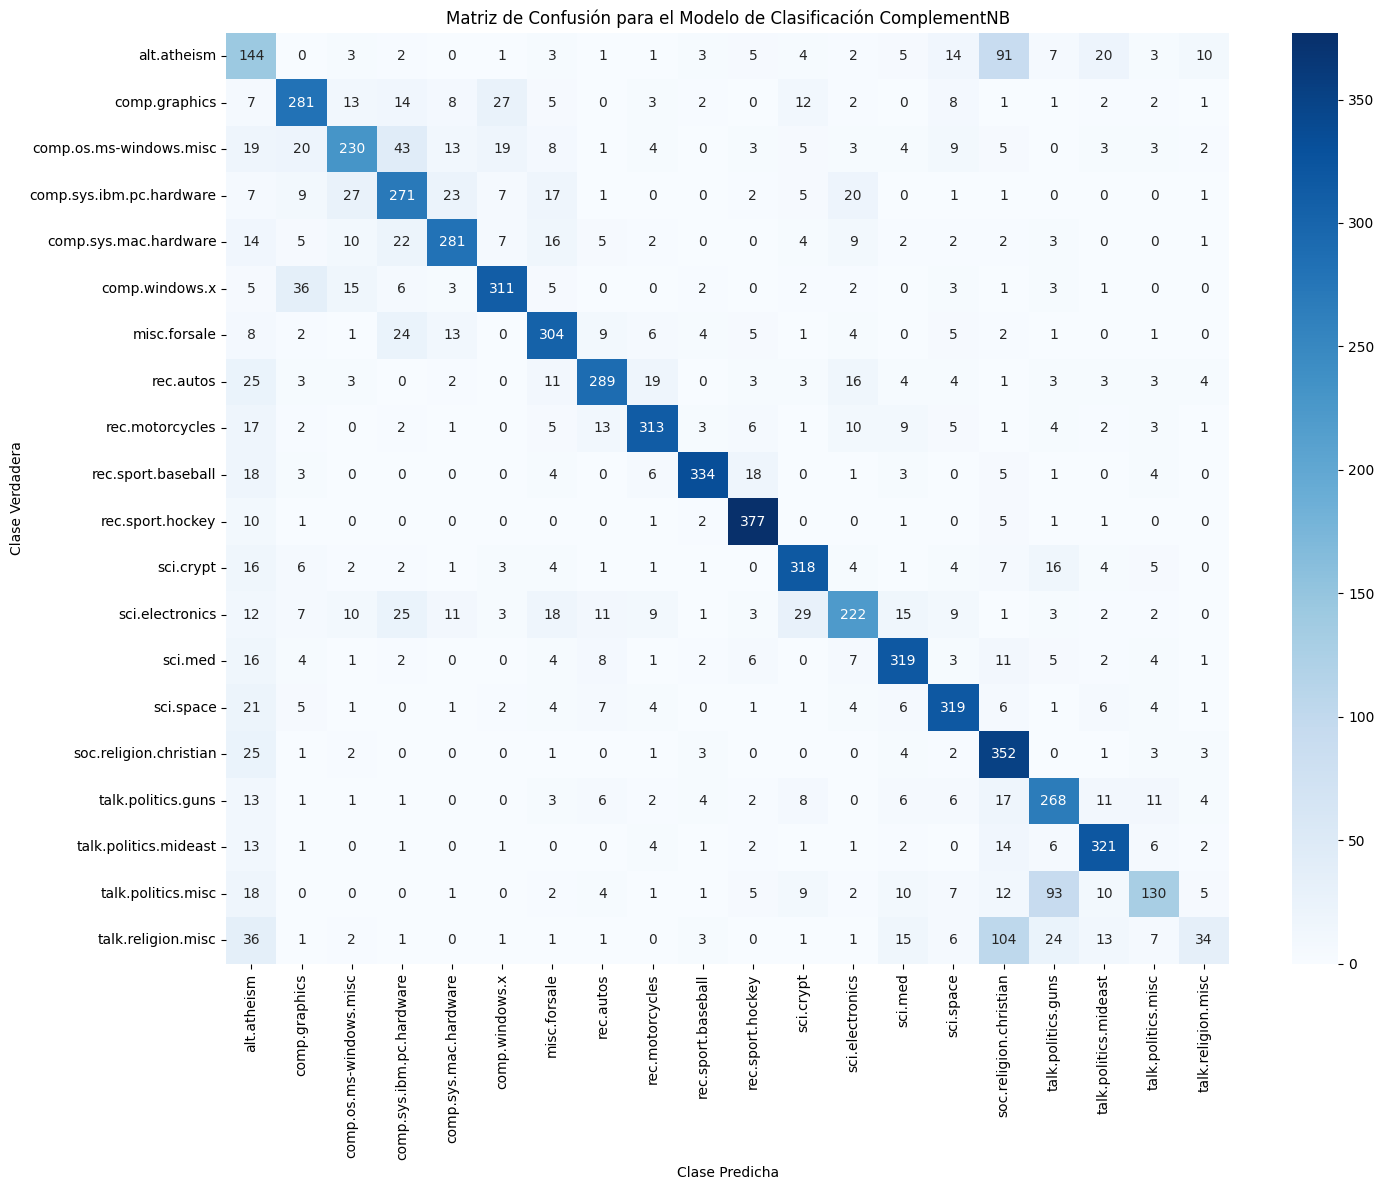

In [41]:
# Generar la matriz de confusión
cm_CNB = confusion_matrix(y_test, y_pred_cnb)

# Visualizar la matriz de confusión
plt.figure(figsize=(15, 12))
sns.heatmap(cm_CNB, annot=True, fmt='d', cmap='Blues',
            xticklabels=newsgroups_test.target_names,
            yticklabels=newsgroups_test.target_names)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión para el Modelo de Clasificación ComplementNB')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Al igual que con `MultinomialNB`, se utilizó `GridSearchCV` con validación cruzada de 3 folds para optimizar los hiperparámetros del modelo `ComplementNB`, explorando además su parámetro propio `norm`. La mejor combinación encontrada fue: `alpha=0.1`, `norm=False`, `max_df=0.7`, `min_df=1`, `tfidf__norm='l2'` y `use_idf=False`.

El mejor F1-Score Macro en validación cruzada (train) fue de **0.7556**, mientras que sobre el conjunto de test se obtuvo **0.6999**. Al igual que en el caso anterior, se observa un leve overfitting dado por la brecha entre ambos valores.

Comparando con `MultinomialNB`, el `ComplementNB` muestra una mejora tanto en entrenamiento (0.7160 → 0.7556) como en test (0.6746 → 0.6999), aunque la diferencia no es modesta: ~0.025 en test. 

#### Comparación de Modelos

Resumimos el F1-Score Macro obtenido por cada enfoque para poder compararlos directamente.

In [42]:
comparison_results = pd.DataFrame({
    'Modelo': ['Zero-Shot (similaridad coseno)', 'MultinomialNB (tuneado)', 'ComplementNB (tuneado)'],
    'F1-Score Macro (Test)': [f1_zero_shot, f1_mnb_test, f1_cnb_test]
})
display(comparison_results)

,Modelo,F1-Score Macro (Test)
0,Zero-Shot (similaridad coseno),0.504987
1,MultinomialNB (tuneado),0.674621
2,ComplementNB (tuneado),0.699892


Comparando con los modelos anteriores, `ComplementNB` muestra una mejora progresiva: el F1-Score Macro en test pasó de **0.5050** (Zero-Shot) a **0.6746** (MultinomialNB) y finalmente a **0.6999** (ComplementNB). Si bien la ganancia entre ambos modelos Naïve Bayes es pequeña, la superioridad del `ComplementNB` es consistente con su diseño: fue concebido específicamente para datasets de texto modelando el complemento de cada clase en lugar de la clase misma, lo que lo hace más robusto en este tipo de problemas.

### (4) Transponer la matriz documento-término

La matriz `X_train` que obtuvimos del `TfidfVectorizer` tiene forma `(n_documentos, n_vocabulario)`: cada fila es un documento representado como un vector de pesos TF-IDF sobre las palabras del vocabulario.

Si transponemos esa matriz obtenemos una matriz término-documento de forma `(n_vocabulario, n_documentos)`: ahora cada fila representa una palabra, y sus columnas son los pesos que tuvo esa palabra en cada uno de los documentos. Esa fila puede pensarse como un vector de la palabra, y por lo tanto podemos medir similaridad coseno entre palabras del mismo modo que hicimos entre documentos.

In [43]:
X_train_words = X_train.T
print(f'Shape de la matriz término-documento: {X_train_words.shape}')

Shape de la matriz término-documento: (101631, 11314)


Elegimos manualmente 5 palabras que sean interpretables y representativas de distintos temas del dataset (autos, computación, medicina, religión y armas), evitando términos demasiado raros o ambiguos. Verificamos primero que estén en el vocabulario aprendido.

In [44]:
palabras = ['car', 'computer', 'doctor', 'god', 'gun']

for palabra in palabras:
    print(f"{palabra}: índice {tfidfvect.vocabulary_.get(palabra)}")

car: índice 25775
computer: índice 28940
doctor: índice 34638
god: índice 43842
gun: índice 44820


Creamos una función análoga a `display_similar_documents` pero para palabras: dado el índice de una palabra en la matriz término-documento, calcula su similaridad coseno contra todas las demás palabras y devuelve las 5 más cercanas.

In [45]:
def palabras_mas_similares(palabra, X_word_matrix, vocabulario, idx2word_dict, top_n=5):
  """
  Calcula las top_n palabras más similares a una palabra dada, usando
  similaridad coseno sobre la matriz término-documento.

  Args:
    palabra (str): palabra de interés (debe estar en el vocabulario).
    X_word_matrix (scipy.sparse.csr_matrix): matriz término-documento (X_train.T).
    vocabulario (dict): diccionario palabra -> índice (tfidfvect.vocabulary_).
    idx2word_dict (dict): diccionario índice -> palabra.
    top_n (int): cantidad de palabras similares a devolver.

  Returns:
    list[tuple[str, float]]: lista de (palabra, similaridad) ordenada de mayor a menor.
  """
  word_idx = vocabulario[palabra]
  sim = cosine_similarity(X_word_matrix[word_idx], X_word_matrix)[0]
  most_similar_idx = np.argsort(sim)[::-1][1:top_n+1]  # excluimos la propia palabra
  return [(idx2word_dict[i], sim[i]) for i in most_similar_idx]

In [46]:
for palabra in palabras:
  similares = palabras_mas_similares(palabra, X_train_words, tfidfvect.vocabulary_, idx2word)
  print(f"\nPalabra: '{palabra}'")
  for palabra_similar, score in similares:
    print(f"  {palabra_similar} ({score:.4f})")


Palabra: 'car'
  cars (0.1797)
  criterium (0.1770)
  civic (0.1748)
  owner (0.1689)
  dealer (0.1681)

Palabra: 'computer'
  decwriter (0.1563)
  deluged (0.1522)
  harkens (0.1522)
  shopper (0.1443)
  the (0.1361)

Palabra: 'doctor'
  receptionist (0.4392)
  clinic (0.3271)
  misbehavior (0.2951)
  urgent (0.2947)
  angering (0.2943)

Palabra: 'god'
  jesus (0.2688)
  bible (0.2616)
  that (0.2560)
  existence (0.2548)
  christ (0.2511)

Palabra: 'gun'
  guns (0.3582)
  crime (0.2441)
  handgun (0.2391)
  homicides (0.2331)
  firearms (0.2328)


#### 4.1 Tabla Resumen de Similaridad entre Palabras

In [47]:
word_similarity_results = []

for palabra in palabras:
    similares = palabras_mas_similares(palabra, X_train_words, tfidfvect.vocabulary_, idx2word)
    word_similarity_results.append({
        'Palabra': palabra,
        'Similar 1': f"{similares[0][0]} ({similares[0][1]:.4f})",
        'Similar 2': f"{similares[1][0]} ({similares[1][1]:.4f})",
        'Similar 3': f"{similares[2][0]} ({similares[2][1]:.4f})",
        'Similar 4': f"{similares[3][0]} ({similares[3][1]:.4f})",
        'Similar 5': f"{similares[4][0]} ({similares[4][1]:.4f})",
    })

df_word_similarity = pd.DataFrame(word_similarity_results)
display(df_word_similarity)

,Palabra,Similar 1,Similar 2,Similar 3,Similar 4,Similar 5
0,car,cars (0.1797),criterium (0.1770),civic (0.1748),owner (0.1689),dealer (0.1681)
1,computer,decwriter (0.1563),deluged (0.1522),harkens (0.1522),shopper (0.1443),the (0.1361)
2,doctor,receptionist (0.4392),clinic (0.3271),misbehavior (0.2951),urgent (0.2947),angering (0.2943)
3,god,jesus (0.2688),bible (0.2616),that (0.2560),existence (0.2548),christ (0.2511)
4,gun,guns (0.3582),crime (0.2441),handgun (0.2391),homicides (0.2331),firearms (0.2328)


#### 4.2 Análisis de Similitud entre Palabras


Los resultados muestran que la calidad de la representación vectorial de cada palabra depende fuertemente de su especificidad temática dentro del corpus.

Las palabras con vocabulario más especializado y acotado a una categoría del dataset presentan vecinos más semánticamente coherentes: **gun** agrupa términos del mismo campo semántico (guns, handgun, firearms) junto con palabras de su contexto habitual en el corpus (crime, homicides); **doctor** encuentra términos médicos (receptionist, clinic, urgent) con las similitudes más altas de la tabla; y **god** recupera términos religiosos (jesus, bible, christ) con buena coherencia.

En cambio, **car** muestra similitudes bajas (~0.17), posiblemente porque el vocabulario automotor se dispersa en muchos documentos de diferentes clases. El caso más llamativo es **computer**, con similitudes muy bajas (~0.15) y vecinos poco interpretables, lo que sugiere que el término aparece en contextos muy variados del corpus sin un vocabulario específico y recurrente que lo rodee.

En general, este enfoque de transponer la matriz documento-término permite obtener representaciones de palabras de forma simple, pero su calidad está limitada por el tamaño y la distribución del corpus: palabras frecuentes en muchos contextos distintos tienden a generar vectores poco informativos.